# Growth Experimentation & Segmentation: Technical Walkthrough

Four independent analyses on a synthetic BNPL fintech's growth and lifecycle data: an A/B test on a repayment-reminder redesign (power analysis, a two-proportion test, and CUPED variance reduction), a difference-in-differences analysis of a non-randomized regional feature rollout, RFM customer segmentation via KMeans, and light NLP topic modeling on synthetic support tickets.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. No proprietary data, models, or results from any employer are used or implied. This is the same fictional company as projects 01 and 02, viewed from the growth/experimentation side.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. A/B test: repayment-reminder redesign

20,000 users randomized into control (current reminder) or treatment (redesigned reminder with a clearer due date and a one-tap repayment link). Primary metric: whether the user repaid on time within 14 days. Secondary metric: revenue in that same 14-day window, with a pre-period revenue covariate available for CUPED.

### 1a. Power analysis

Before running a test, the sample size should be sized to the smallest effect worth detecting. Using a two-proportion test with a 34% baseline conversion rate, alpha=0.05, and 80% power, smaller minimum detectable effects require sharply more traffic.

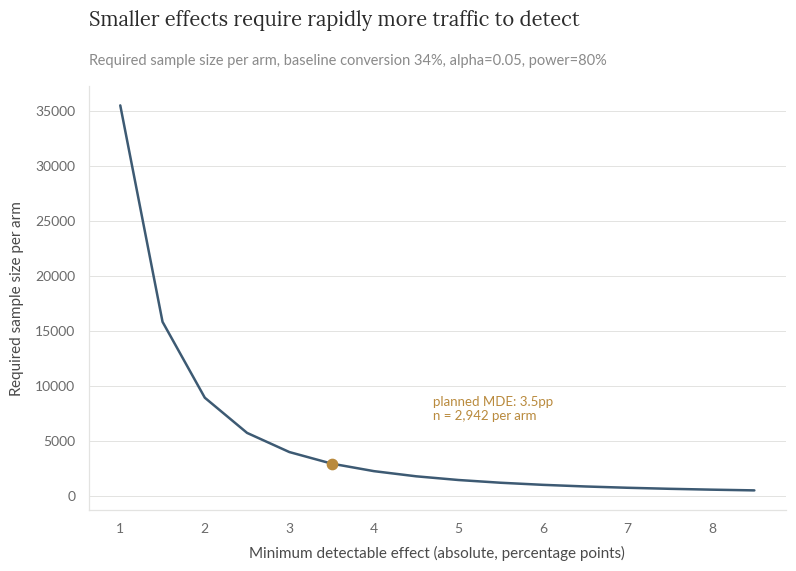

Planned test: MDE=3.5pp, required n/arm=2,942


In [2]:
from statsmodels.stats.power import NormalIndPower

ALPHA = 0.05
POWER_TARGET = 0.80
BASELINE_RATE = 0.34

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

analysis = NormalIndPower()
mde_range = np.arange(0.01, 0.09, 0.005)
sample_sizes = [analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + m)),
                                      alpha=ALPHA, power=POWER_TARGET, alternative="two-sided") for m in mde_range]

planned_mde = 0.035
planned_n = analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + planned_mde)),
                                  alpha=ALPHA, power=POWER_TARGET, alternative="two-sided")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mde_range * 100, sample_sizes, color=SLATE, linewidth=1.8)
ax.scatter([planned_mde * 100], [planned_n], color=MUTED_AMBER, s=55, zorder=4)
ax.annotate(f"planned MDE: 3.5pp\nn = {planned_n:,.0f} per arm", xy=(planned_mde * 100, planned_n),
            xytext=(planned_mde * 100 + 1.2, planned_n + 4000), fontsize=9.5, color=MUTED_AMBER)
style_ax(ax, title="Smaller effects require rapidly more traffic to detect",
         subtitle=f"Required sample size per arm, baseline conversion {BASELINE_RATE:.0%}, alpha={ALPHA}, power={POWER_TARGET:.0%}",
         xlabel="Minimum detectable effect (absolute, percentage points)", ylabel="Required sample size per arm")
plt.show()
print(f"Planned test: MDE=3.5pp, required n/arm={planned_n:,.0f}")

### 1b. Standard analysis: two-proportion z-test

The actual test ran with about 10k users per arm, well above the planned minimum.

In [3]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

exp = pd.read_csv("../data/experiment_users.csv")
SOURCE_EXP = f"Source: synthetic BNPL experiment data · n = {len(exp):,} users"

counts = exp.groupby("arm")["converted_post_14d"].agg(["sum", "count"])
n_control, n_treat = counts.loc["control", "count"], counts.loc["treatment", "count"]
x_control, x_treat = counts.loc["control", "sum"], counts.loc["treatment", "sum"]
p_control, p_treat = x_control / n_control, x_treat / n_treat

z_stat, p_value = proportions_ztest([x_treat, x_control], [n_treat, n_control], alternative="two-sided")
lift_abs = p_treat - p_control
se_diff = np.sqrt(p_control * (1 - p_control) / n_control + p_treat * (1 - p_treat) / n_treat)
ci_diff = (lift_abs - 1.96 * se_diff, lift_abs + 1.96 * se_diff)

print(f"Control: {p_control:.4f} ({x_control}/{n_control})  Treatment: {p_treat:.4f} ({x_treat}/{n_treat})")
print(f"Absolute lift: {lift_abs*100:.2f}pp, 95% CI [{ci_diff[0]*100:.2f}, {ci_diff[1]*100:.2f}]pp")
print(f"z={z_stat:.3f}, p={p_value:.5f}")

Control: 0.3368 (3413/10135)  Treatment: 0.3811 (3760/9865)
Absolute lift: 4.44pp, 95% CI [3.11, 5.77]pp
z=6.544, p=0.00000


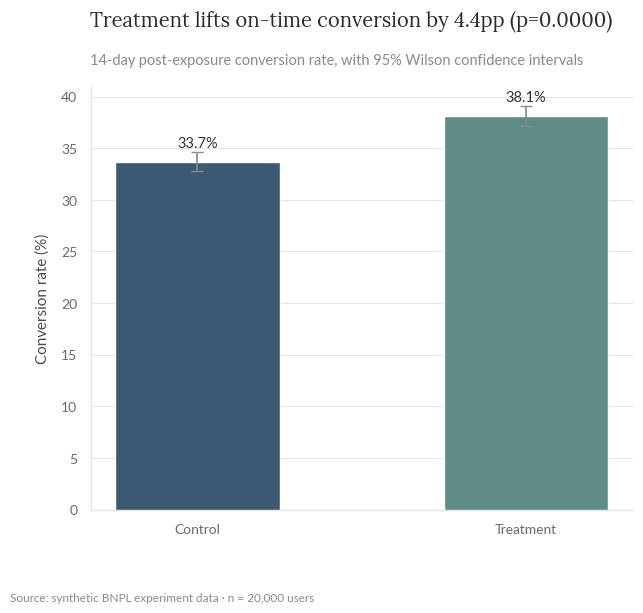

In [4]:
ci_control = proportion_confint(x_control, n_control, alpha=ALPHA, method="wilson")
ci_treat = proportion_confint(x_treat, n_treat, alpha=ALPHA, method="wilson")

fig, ax = plt.subplots(figsize=(7, 5.5))
arms = ["Control", "Treatment"]
rates = [p_control * 100, p_treat * 100]
errs = [(p_control - ci_control[0]) * 100, (p_treat - ci_treat[0]) * 100]
ax.bar(arms, rates, yerr=[errs, errs], color=[SLATE, MUTED_TEAL], width=0.5, zorder=3,
       error_kw={"ecolor": GREY, "elinewidth": 1.2, "capsize": 4})
for i, v in enumerate(rates):
    ax.text(i, v + max(errs) + 0.5, f"{v:.1f}%", ha="center", fontsize=10.5, color="#333")
style_ax(ax, title=f"Treatment lifts on-time conversion by {lift_abs*100:.1f}pp (p={p_value:.4f})",
         subtitle="14-day post-exposure conversion rate, with 95% Wilson confidence intervals", ylabel="Conversion rate (%)")
add_footnote(fig, SOURCE_EXP)
plt.show()

### 1c. CUPED: variance reduction on the revenue metric

The primary metric is binary conversion, but revenue is a natural secondary metric with much higher variance. CUPED uses each user's pre-period revenue (unaffected by treatment, since it's measured before assignment) to strip out variance unrelated to the treatment effect, tightening the confidence interval on the same sample.

In [5]:
from scipy import stats

y = exp["revenue_post_14d_usd"].values
x = exp["revenue_pre_30d_usd"].values
theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
exp["revenue_adj"] = y - theta * (x - x.mean())

print(f"Pre/post revenue correlation: {np.corrcoef(x, y)[0,1]:.3f}")
print(f"CUPED theta: {theta:.3f}")

def arm_stats(col):
    c = exp[exp.arm == "control"][col]
    t = exp[exp.arm == "treatment"][col]
    diff = t.mean() - c.mean()
    se = np.sqrt(c.var(ddof=1) / len(c) + t.var(ddof=1) / len(t))
    ci = (diff - 1.96 * se, diff + 1.96 * se)
    _, p_val = stats.ttest_ind(t, c, equal_var=False)
    return diff, se, ci, p_val

diff_raw, se_raw, ci_raw, p_raw = arm_stats("revenue_post_14d_usd")
diff_adj, se_adj, ci_adj, p_adj = arm_stats("revenue_adj")
ci_width_reduction = 1 - se_adj / se_raw

print(f"Raw lift: {diff_raw:.2f} USD, 95% CI [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}], p={p_raw:.4f}")
print(f"CUPED lift: {diff_adj:.2f} USD, 95% CI [{ci_adj[0]:.2f}, {ci_adj[1]:.2f}], p={p_adj:.4f}")
print(f"CI width reduction from CUPED: {ci_width_reduction:.1%}")

Pre/post revenue correlation: 0.459
CUPED theta: 0.440
Raw lift: 2.51 USD, 95% CI [1.15, 3.87], p=0.0003
CUPED lift: 3.04 USD, 95% CI [1.84, 4.25], p=0.0000
CI width reduction from CUPED: 11.2%


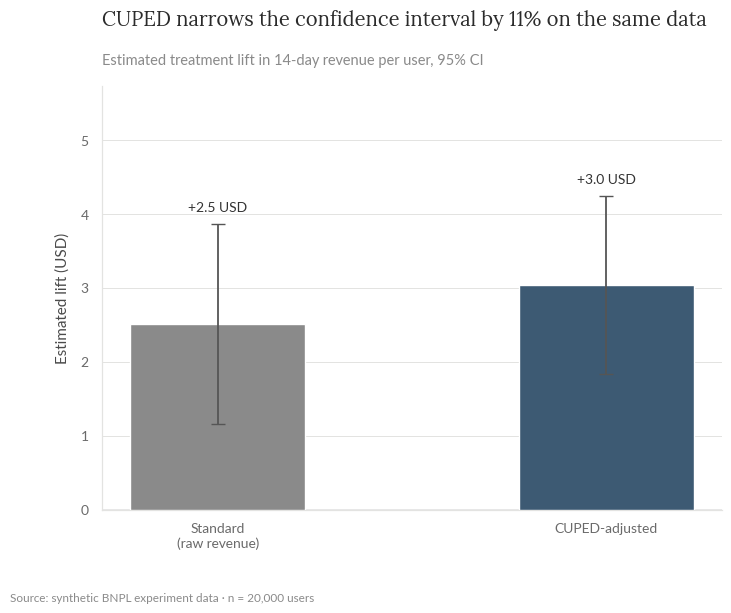

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["Standard\n(raw revenue)", "CUPED-adjusted"]
diffs = [diff_raw, diff_adj]
errs = [1.96 * se_raw, 1.96 * se_adj]
ax.bar(labels, diffs, yerr=errs, color=[GREY, SLATE], width=0.45, zorder=3,
       error_kw={"ecolor": "#555", "elinewidth": 1.3, "capsize": 5})
ax.axhline(0, color=GREY, linewidth=1)
ylim_max = max(d + e for d, e in zip(diffs, errs)) * 1.35
ax.set_ylim(0, ylim_max)
for i, v in enumerate(diffs):
    ax.text(i, v + errs[i] + ylim_max * 0.03, f"+{v:.1f} USD", ha="center", fontsize=10, color="#333")
style_ax(ax, title=f"CUPED narrows the confidence interval by {ci_width_reduction:.0%} on the same data",
         subtitle="Estimated treatment lift in 14-day revenue per user, 95% CI", ylabel="Estimated lift (USD)")
add_footnote(fig, SOURCE_EXP)
plt.show()

CUPED doesn't change what's being measured, it changes how precisely it's measured with the traffic already collected. That precision gain is effectively free: no extra users, no extra runtime, just a pre-period covariate that most experimentation platforms already have on hand.

## 2. Difference-in-differences: regional feature rollout

A new in-app collections feature went to 20 of 40 regions first, chosen by business priority rather than randomly. A naive before/after comparison in the treated regions would confound the treatment effect with any shared time trend. Diff-in-differences nets that out by comparing the *change* in treated regions against the *change* in control regions over the same window.

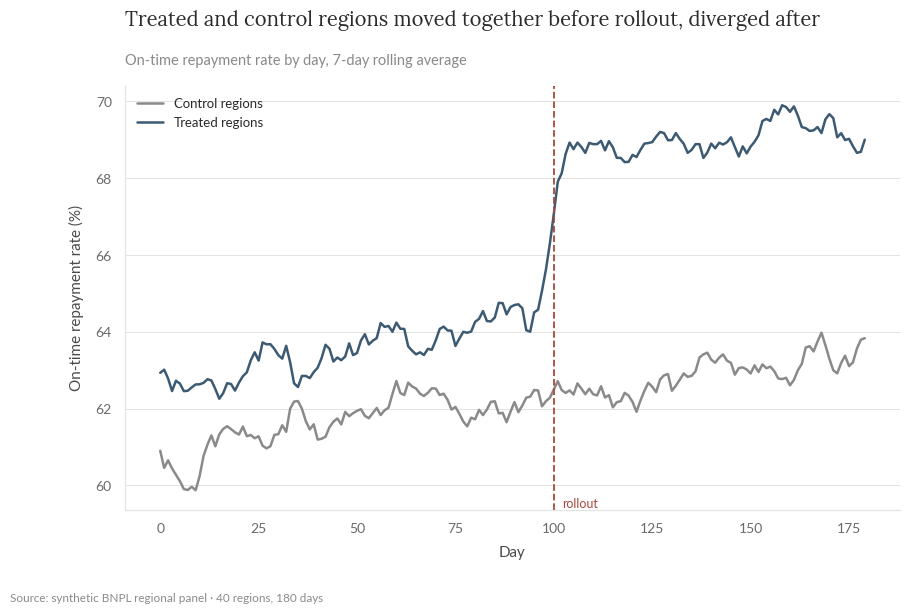

In [7]:
rollout = pd.read_csv("../data/regional_rollout.csv")
SOURCE_ROLLOUT = f"Source: synthetic BNPL regional panel · {rollout.region_id.nunique()} regions, {rollout.day.nunique()} days"
ROLLOUT_DAY = 100

daily = rollout.groupby(["day", "group"])["on_time_rate"].mean().reset_index()
pivot = daily.pivot(index="day", columns="group", values="on_time_rate").rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(pivot.index, pivot["control"] * 100, color=GREY, linewidth=1.8, label="Control regions")
ax.plot(pivot.index, pivot["treated"] * 100, color=SLATE, linewidth=1.8, label="Treated regions")
ax.axvline(ROLLOUT_DAY, color=MUTED_RED, linestyle="--", linewidth=1.3)
ax.text(ROLLOUT_DAY + 2, ax.get_ylim()[0], "rollout", fontsize=9, color=MUTED_RED, va="bottom")
style_ax(ax, title="Treated and control regions moved together before rollout, diverged after",
         subtitle="On-time repayment rate by day, 7-day rolling average", xlabel="Day", ylabel="On-time repayment rate (%)")
ax.legend(loc="upper left", fontsize=9.5)
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()

### Checking the parallel-trends assumption

Diff-in-differences is only valid if treated and control regions would have moved in parallel absent treatment. That can't be proven, but it can be checked in the pre-period: if the gap between groups was already trending before rollout, the post-period estimate can't be trusted.

In [8]:
import statsmodels.formula.api as smf

pre = rollout[~rollout.post_rollout].copy()
pre["treated_flag"] = (pre.group == "treated").astype(int)
placebo_model = smf.wls("on_time_rate ~ day * treated_flag", data=pre, weights=pre["n_customers"]).fit()
coef = placebo_model.params["day:treated_flag"]
pval = placebo_model.pvalues["day:treated_flag"]
print(f"Pre-period trend difference (day x treated): {coef:.6f}/day, p={pval:.3f}")
print("No significant pre-trend difference: the parallel-trends assumption looks reasonable here.")

Pre-period trend difference (day x treated): 0.000026/day, p=0.693
No significant pre-trend difference: the parallel-trends assumption looks reasonable here.


### DiD estimate: region and day fixed effects

Region fixed effects absorb each region's baseline level; day fixed effects absorb any shared time shock. Since `treated_flag` is time-invariant per region and `post_flag` is the same calendar cutoff for every region, both main effects are redundant given the fixed effects and are dropped, leaving only the `treated_flag:post_flag` interaction to estimate, the actual DiD effect. Standard errors are clustered by region since observations within a region aren't independent over time.

In [9]:
d = rollout.copy()
d["treated_flag"] = (d.group == "treated").astype(int)
d["post_flag"] = d.post_rollout.astype(int)

model = smf.wls(
    "on_time_rate ~ treated_flag:post_flag + C(region_id) + C(day)",
    data=d, weights=d["n_customers"],
).fit(cov_type="cluster", cov_kwds={"groups": d["region_id"]})

did_coef = model.params["treated_flag:post_flag"]
did_se = model.bse["treated_flag:post_flag"]
did_p = model.pvalues["treated_flag:post_flag"]
ci = (did_coef - 1.96 * did_se, did_coef + 1.96 * did_se)

means = d.groupby(["group", "post_rollout"])["on_time_rate"].mean().unstack()
simple_did = (means.loc["treated", True] - means.loc["treated", False]) - (means.loc["control", True] - means.loc["control", False])

print(f"Simple 2x2 DiD: {simple_did*100:.2f}pp")
print(f"Fixed-effects DiD: {did_coef*100:.2f}pp, 95% CI [{ci[0]*100:.2f}, {ci[1]*100:.2f}]pp, p={did_p:.5f}")

Simple 2x2 DiD: 4.25pp
Fixed-effects DiD: 4.30pp, 95% CI [3.96, 4.63]pp, p=0.00000


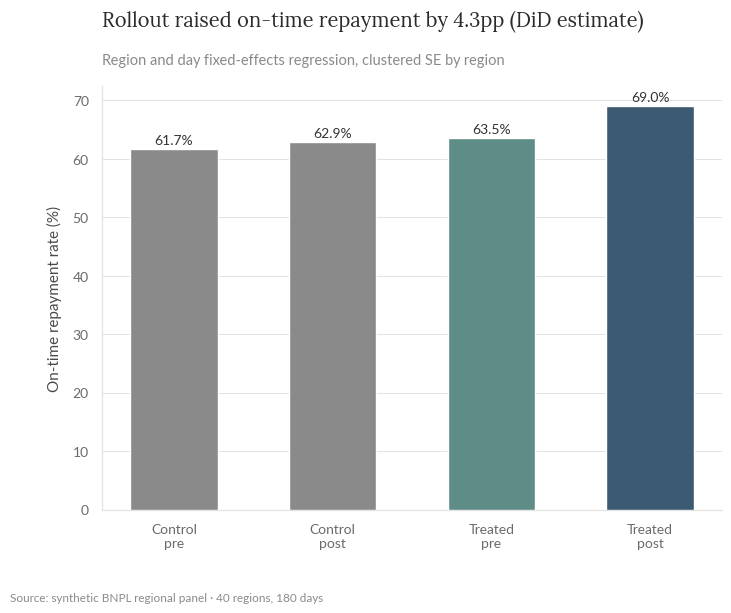

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cats = ["Control\npre", "Control\npost", "Treated\npre", "Treated\npost"]
vals = [means.loc["control", False] * 100, means.loc["control", True] * 100,
        means.loc["treated", False] * 100, means.loc["treated", True] * 100]
ax.bar(cats, vals, color=[GREY, GREY, MUTED_TEAL, SLATE], width=0.55, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10, color="#333")
style_ax(ax, title=f"Rollout raised on-time repayment by {did_coef*100:.1f}pp (DiD estimate)",
         subtitle="Region and day fixed-effects regression, clustered SE by region", ylabel="On-time repayment rate (%)")
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()

The simple 2x2 mean comparison and the fixed-effects regression agree closely (4.25pp vs 4.30pp), which is a useful cross-check: the more sophisticated model isn't manufacturing an effect that isn't visible in the raw group means.

## 3. RFM customer segmentation

Recency, frequency, and monetary value, log-transformed and standardized (their raw scales are wildly different and right-skewed), clustered with KMeans. The number of clusters is chosen by silhouette score rather than fixed in advance.

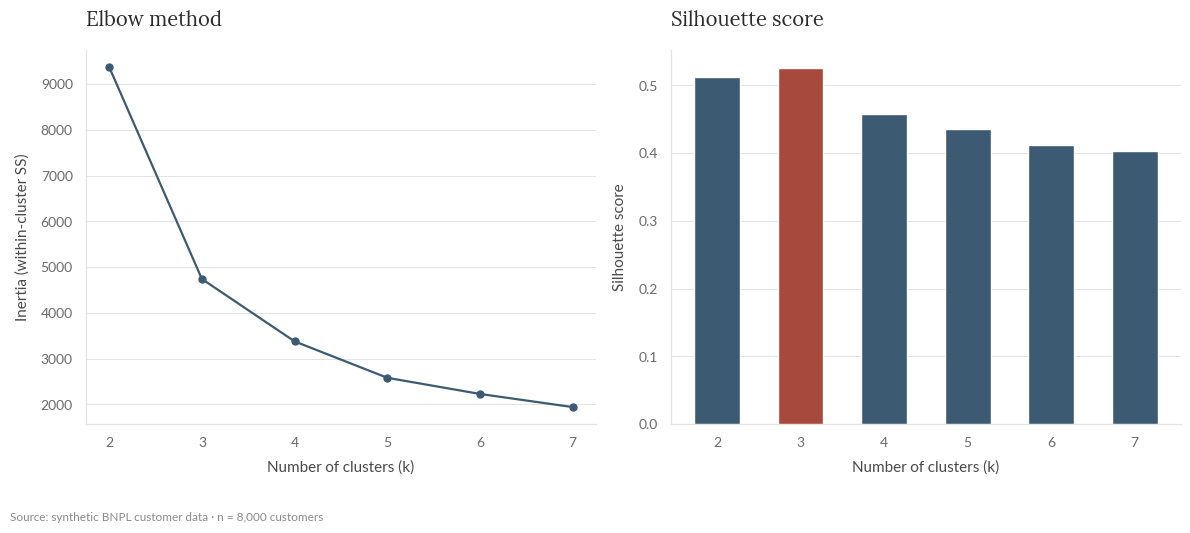

Selected k=3


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rfm_raw = pd.read_csv("../data/rfm_customers.csv")
SOURCE_RFM = f"Source: synthetic BNPL customer data · n = {len(rfm_raw):,} customers"

rfm = rfm_raw[["customer_id", "recency_days", "frequency", "monetary_usd"]].copy()
log_features = np.column_stack([np.log1p(rfm["recency_days"]), np.log1p(rfm["frequency"]), np.log1p(rfm["monetary_usd"])])
X = StandardScaler().fit_transform(log_features)

K_RANGE = range(2, 8)
inertias, sil_scores = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=7, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(K_RANGE), inertias, color=SLATE, marker="o", markersize=5, linewidth=1.6)
style_ax(axes[0], title="Elbow method", xlabel="Number of clusters (k)", ylabel="Inertia (within-cluster SS)")
colors = [MUTED_RED if k == best_k else SLATE for k in K_RANGE]
axes[1].bar([str(k) for k in K_RANGE], sil_scores, color=colors, zorder=3, width=0.55)
style_ax(axes[1], title="Silhouette score", xlabel="Number of clusters (k)", ylabel="Silhouette score")
plt.tight_layout()
add_footnote(fig, SOURCE_RFM)
plt.show()
print(f"Selected k={best_k}")

In [12]:
NAME_SETS = {2: ["Champions", "Dormant"], 3: ["Champions", "Loyal", "Dormant"],
             4: ["Champions", "Loyal", "At risk", "Dormant"],
             5: ["Champions", "Loyal", "Promising", "At risk", "Dormant"],
             6: ["Champions", "Loyal", "Promising", "At risk", "Lapsed", "Dormant"]}

km = KMeans(n_clusters=best_k, random_state=7, n_init=10).fit(X)
rfm["cluster"] = km.labels_
profile = rfm.groupby("cluster")[["recency_days", "frequency", "monetary_usd"]].mean()

r_rank = profile["recency_days"].rank()
f_rank = profile["frequency"].rank(ascending=False)
m_rank = profile["monetary_usd"].rank(ascending=False)
order = (r_rank + f_rank + m_rank).sort_values().index
names = NAME_SETS[best_k]
label_map = {seg: names[i] for i, seg in enumerate(order)}

rfm["segment"] = rfm["cluster"].map(label_map)
profile.index = profile.index.map(label_map)
profile = profile.reindex(names)
profile.round(1)

,recency_days,frequency,monetary_usd
cluster,,,
Champions,10.8,24.5,12652.7
Loyal,97.6,9.8,4133.7
Dormant,311.1,2.6,828.8


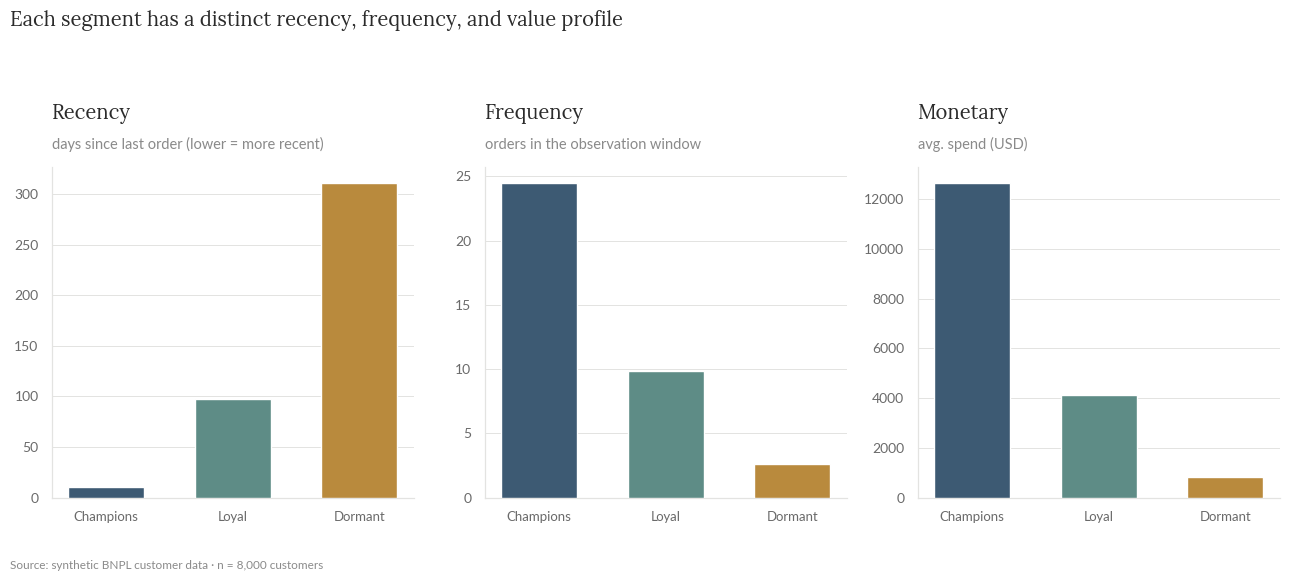

In [13]:
panels = [("recency_days", "Recency", "days since last order (lower = more recent)"),
          ("frequency", "Frequency", "orders in the observation window"),
          ("monetary_usd", "Monetary", "avg. spend (USD)")]
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, label, sublabel) in zip(axes, panels):
    ax.bar(profile.index, profile[col], color=PALETTE[:len(profile)], width=0.6, zorder=3)
    style_ax(ax, title=label, subtitle=sublabel, grid_axis="y")
    ax.tick_params(axis="x", labelsize=9.5)
fig.suptitle("Each segment has a distinct recency, frequency, and value profile", x=0.01, y=1.06,
             ha="left", fontsize=14.5, fontfamily="Lora", color="#2B2B2B")
plt.tight_layout()
add_footnote(fig, SOURCE_RFM)
plt.show()

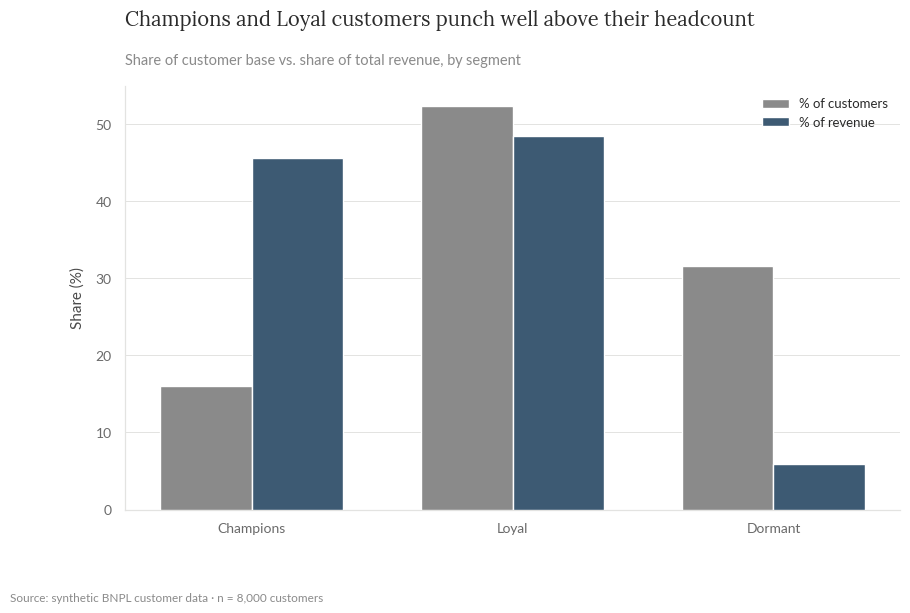

,customers,revenue,pct_customers,pct_revenue
cluster,,,,
Champions,1286,16271336.4,16.1,45.6
Loyal,4184,17295247.7,52.3,48.5
Dormant,2530,2096893.5,31.6,5.9


In [14]:
seg_summary = rfm.groupby("segment").agg(customers=("customer_id", "count"), revenue=("monetary_usd", "sum")).reindex(profile.index)
seg_summary["pct_customers"] = seg_summary["customers"] / seg_summary["customers"].sum() * 100
seg_summary["pct_revenue"] = seg_summary["revenue"] / seg_summary["revenue"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(seg_summary))
width = 0.35
ax.bar(x - width/2, seg_summary["pct_customers"], width, color=GREY, label="% of customers", zorder=3)
ax.bar(x + width/2, seg_summary["pct_revenue"], width, color=SLATE, label="% of revenue", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(seg_summary.index)
style_ax(ax, title="Champions and Loyal customers punch well above their headcount",
         subtitle="Share of customer base vs. share of total revenue, by segment", ylabel="Share (%)")
ax.legend(loc="upper right", fontsize=9.5)
add_footnote(fig, SOURCE_RFM)
plt.show()
seg_summary.round(1)

## 4. Light NLP: support ticket topic modeling

TF-IDF vectorizes 1,500 synthetic support ticket texts, and NMF (non-negative matrix factorization) extracts latent topics. The synthetic data was generated from five known underlying categories; that ground truth is used once, purely as a validation check, since it's not something a real, unlabeled ticket queue would have.

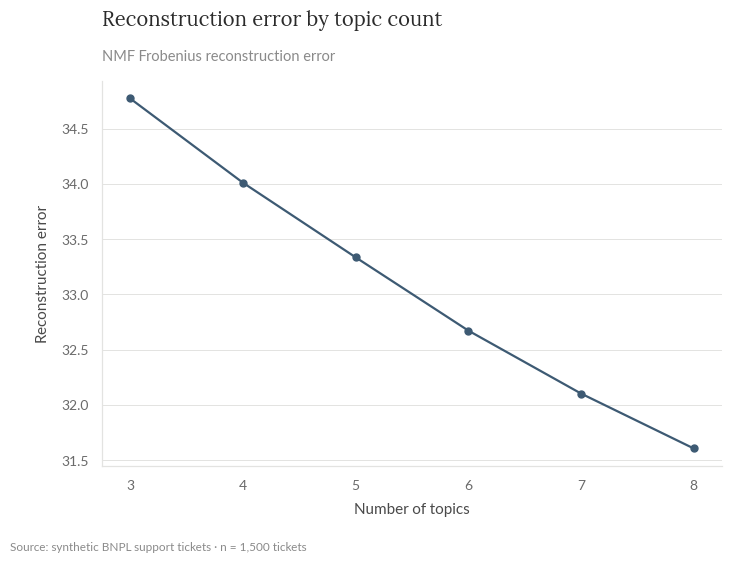

Reconstruction error decreases smoothly with no sharp elbow; 5 topics is chosen as a reasonable
operational category count for a support team, then checked for coherence below.


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

tickets = pd.read_csv("../data/support_tickets.csv")
SOURCE_TICKETS = f"Source: synthetic BNPL support tickets · n = {len(tickets):,} tickets"

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.6, min_df=3, ngram_range=(1, 1))
X_text = vectorizer.fit_transform(tickets["ticket_text"])
feature_names = vectorizer.get_feature_names_out()

TOPIC_RANGE = range(3, 9)
errors = []
for k in TOPIC_RANGE:
    nmf_k = NMF(n_components=k, init="nndsvda", random_state=7, max_iter=400)
    nmf_k.fit(X_text)
    errors.append(nmf_k.reconstruction_err_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(TOPIC_RANGE), errors, color=SLATE, marker="o", markersize=5, linewidth=1.6)
style_ax(ax, title="Reconstruction error by topic count", subtitle="NMF Frobenius reconstruction error",
         xlabel="Number of topics", ylabel="Reconstruction error")
add_footnote(fig, SOURCE_TICKETS)
plt.show()
print("Reconstruction error decreases smoothly with no sharp elbow; 5 topics is chosen as a reasonable")
print("operational category count for a support team, then checked for coherence below.")

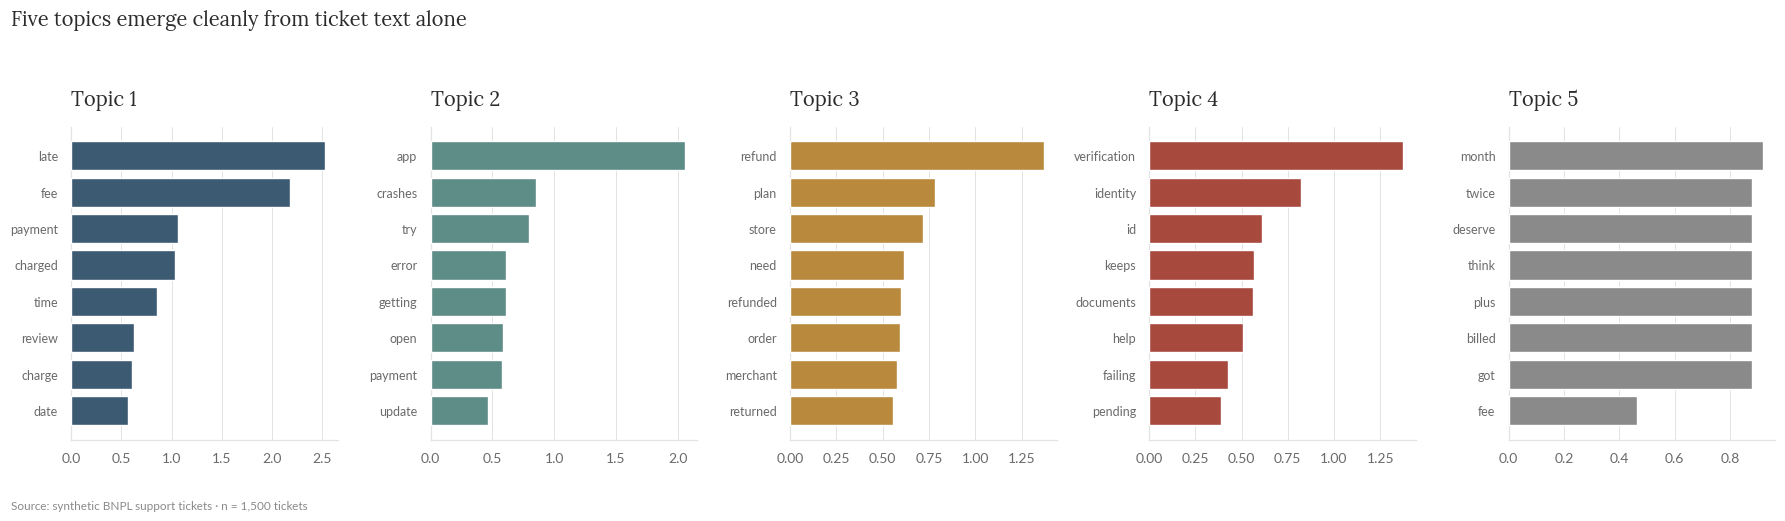

In [16]:
N_TOPICS = 5
nmf = NMF(n_components=N_TOPICS, init="nndsvda", random_state=7, max_iter=400)
W = nmf.fit_transform(X_text)
tickets["topic"] = W.argmax(axis=1)

fig, axes = plt.subplots(1, N_TOPICS, figsize=(18, 4.5))
for i, ax in enumerate(axes):
    comp = nmf.components_[i]
    top_idx = comp.argsort()[::-1][:8]
    ax.barh(range(8)[::-1], comp[top_idx], color=PALETTE[i % len(PALETTE)], zorder=3)
    ax.set_yticks(range(8)[::-1])
    ax.set_yticklabels([feature_names[j] for j in top_idx], fontsize=9)
    style_ax(ax, title=f"Topic {i+1}", grid_axis="x")
fig.suptitle("Five topics emerge cleanly from ticket text alone", x=0.01, y=1.05,
             ha="left", fontsize=14.5, fontfamily="Lora", color="#2B2B2B")
plt.tight_layout()
add_footnote(fig, SOURCE_TICKETS)
plt.show()

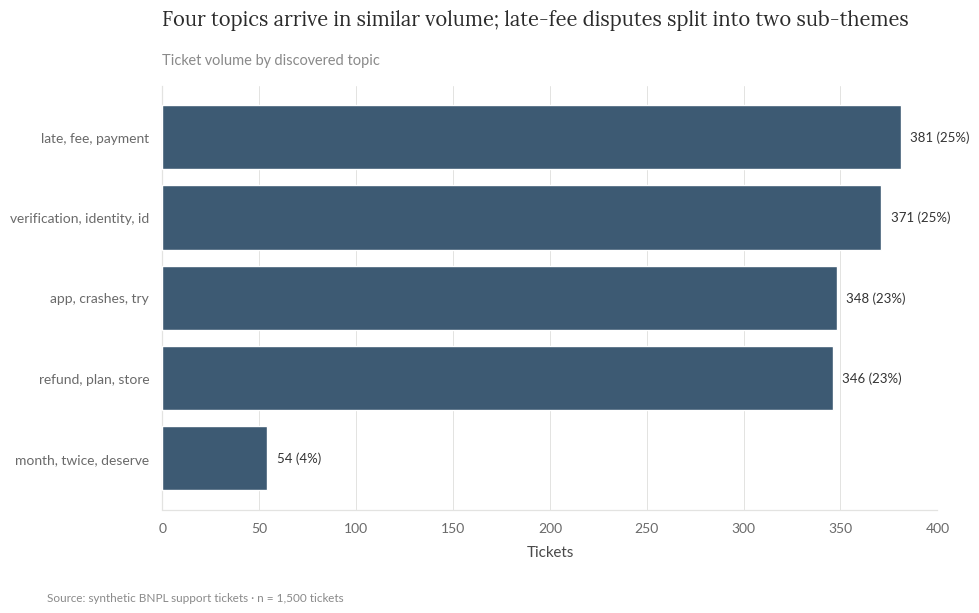

In [17]:
topic_labels = {i: ", ".join([feature_names[j] for j in nmf.components_[i].argsort()[::-1][:3]]) for i in range(N_TOPICS)}
tickets["topic_label"] = tickets["topic"].map(topic_labels)

vol = tickets["topic_label"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(vol.index, vol.values, color=SLATE, zorder=3)
for i, v in enumerate(vol.values):
    ax.text(v + 5, i, f"{v} ({v/len(tickets):.0%})", va="center", fontsize=9.5, color="#333")
style_ax(ax, title="Four topics arrive in similar volume; late-fee disputes split into two sub-themes",
         subtitle="Ticket volume by discovered topic", xlabel="Tickets", grid_axis="x")
add_footnote(fig, SOURCE_TICKETS)
plt.show()

In [18]:
cross = pd.crosstab(tickets["true_topic"], tickets["topic"])
match = cross.idxmax(axis=0)
purity = sum(cross.loc[match[t], t] for t in cross.columns) / len(tickets)
print(f"Cluster purity vs. ground-truth topic (synthetic data validation only): {purity:.1%}")
cross

Cluster purity vs. ground-truth topic (synthetic data validation only): 85.3%


topic,0,1,2,3,4
true_topic,,,,,
app_bug,0,336,0,0,0
general_inquiry,9,12,91,108,0
kyc_verification,0,0,0,263,0
late_fee_dispute,372,0,0,0,54
refund_request,0,0,255,0,0


Purity of 85% is a solid recovery of the underlying structure from text alone. The confusion is concentrated in `general_inquiry`, which scatters across several discovered topics rather than forming a distinct one of its own. That's a sensible failure mode, general questions about credit limits, interest, and rewards share vocabulary with the other categories rather than having a distinct lexical signature. In a real deployment, that topic would likely need a rule-based fallback or a supervised layer on top of the unsupervised topics rather than relying on NMF alone.

## 5. Limitations

- The A/B test, RFM segmentation, and topic modeling all use synthetic data engineered to have reasonably clean underlying structure. Real data is messier: real experiments have novelty effects and network interference between users, real customer bases have more continuous behavior than discrete archetypes, and real support tickets have far more lexical variety than a small set of templates.
- The regional rollout's parallel-trends check only covers the observed pre-period; it can't rule out an unobserved shock that happened to coincide with the rollout date in treated regions.
- CUPED's variance reduction depends on how correlated the pre-period covariate is with the outcome; a weaker covariate would produce a smaller (or negligible) gain.
- The topic model's `general_inquiry` category not forming its own cluster is a real limitation of unsupervised NMF on short, templated text, not something the analysis smooths over.